In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/customer-churn-raw.csv")

In [4]:
df.shape

(7043, 21)

In [5]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
623,5148-HKFIR,Female,0,No,No,20,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,406.95,No
4534,2607-FBDFF,Male,0,No,No,1,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,No,Credit card (automatic),49.00,49,No
3047,1550-LOAHA,Female,0,Yes,No,32,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),84.15,2585.95,Yes
141,4080-OGPJL,Female,0,No,No,8,Yes,Yes,DSL,Yes,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,71.15,563.65,Yes
1406,9337-SRRNI,Male,0,No,Yes,66,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.30,1673.8,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


SeniorCitizen is actually a categorical hence the 25%-50%-75% distribution is not propoer

75% customers have tenure less than 55 months

Average Monthly charges are USD 64.76 whereas 25% customers pay more than USD 89.85 per month

### Data Cleaning

In [10]:
telco_data = df.copy()

Total charges should be numeric value. Let's convert it numeric data type

In [11]:
telco_data.TotalCharges = pd.to_numeric(telco_data.TotalCharges, errors='coerce')
telco_data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Handling Missing values

Since the % of these records compared to total dataset is very low, it is safe to ignore them from further processing.

In [12]:
#Removing missing values 
telco_data.dropna(how = 'any', inplace = True)

## Data Exploration

In [15]:
def plot_text(bars,counts,percentages):
    for bar, count, percentage in zip(bars, counts, percentages):
         plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'{count}\n({percentage:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

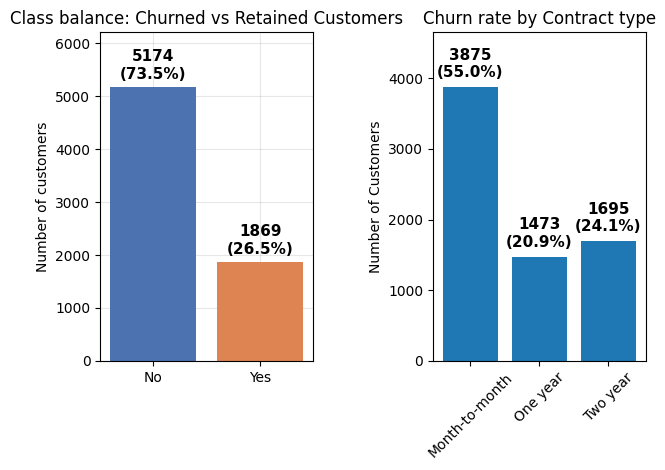

In [30]:
plt.subplot(1,2,1)
counts = df.groupby('Churn')['Churn'].value_counts()
total_counts = counts.values.sum()
percentages = [(count/total_counts)*100 for count in counts]
bars = plt.bar(counts.index,counts.values,color=["#4C72B0", "#DD8452"])
plot_text(bars,counts,percentages)
plt.title("Class balance: Churned vs Retained Customers")
plt.ylabel("Number of customers")
plt.xlabel("")
plt.ylim(0, max(counts) * 1.2)
# Grid
plt.grid(axis='both', alpha=0.3)

# Keep grid behind bars
plt.gca().set_axisbelow(True)

plt.subplot(1,2,2)
contract_type = df.groupby('Contract')['Contract'].value_counts()
total_ct = contract_type.values.sum()
percentage_ct = [(count/total_ct)*100 for count in contract_type]
contract_bar = plt.bar(contract_type.index,contract_type.values)
plot_text(contract_bar,contract_type,percentage_ct)
plt.title("Churn rate by Contract type")
plt.ylabel('Number of Customers')
plt.ylim(0, max(contract_type.values) * 1.2)
plt.xticks(rotation=45)
plt.tight_layout(w_pad = 4.0)
plt.show()


- In dataset churned coustomer is lower than non-churned customer. So, output data is in imbalanced form.
- In contract type month-to-month churn rate is heigher than one year and two year.

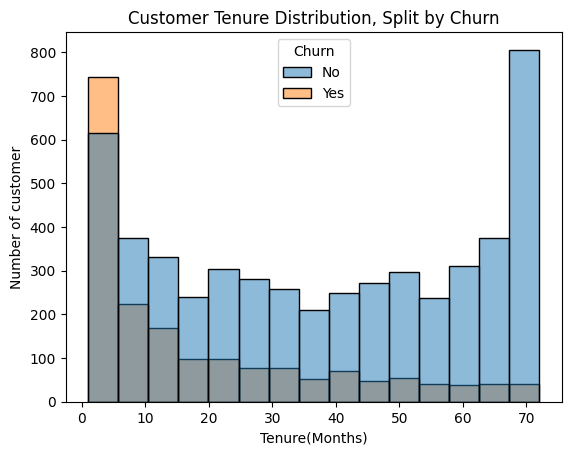

In [46]:
sns.histplot(data= telco_data,x='tenure',hue='Churn')
plt.xlabel('Tenure(Months)')
plt.ylabel('Number of customer')
plt.title("Customer Tenure Distribution, Split by Churn")
plt.show()

- Customers with shorter tenure are considerably more likely to churn,
while long-tenure customers are much more likely to remain with the company.

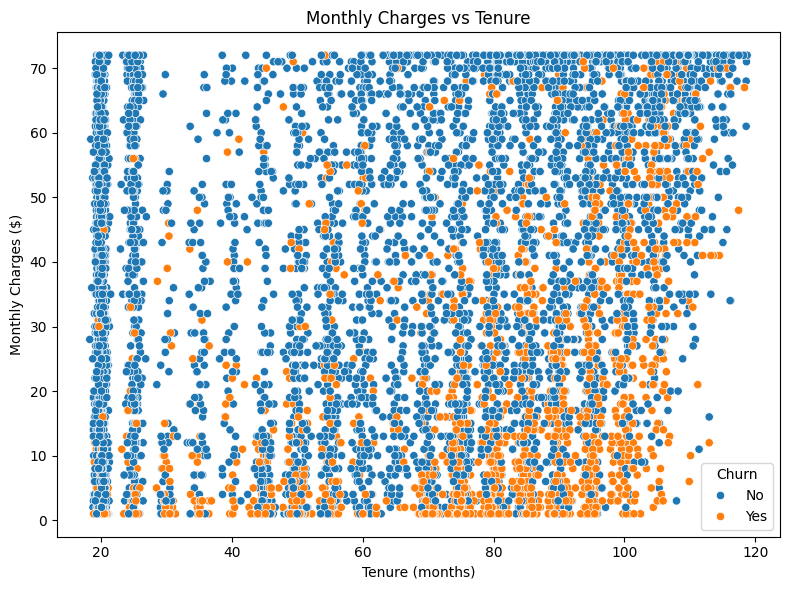

In [50]:
plt.figure(figsize=(8,6))
sns.scatterplot(data = telco_data, x='MonthlyCharges',y='tenure',hue='Churn')
plt.title("Monthly Charges vs Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charges ($)")
plt.tight_layout()

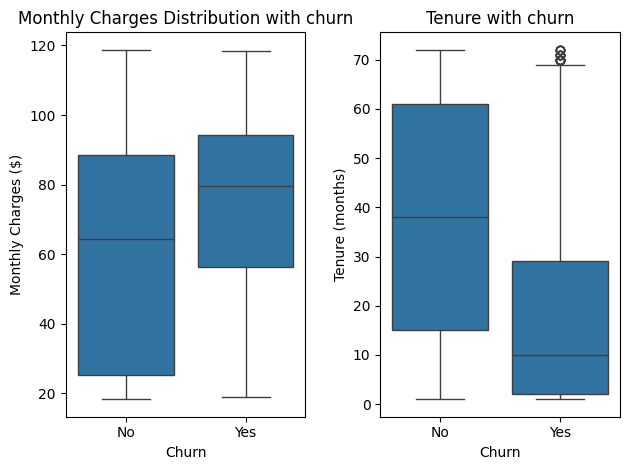

In [104]:
plt.subplot(1,2,1)
sns.boxplot(data=telco_data,x='Churn',y='MonthlyCharges')
plt.title("Monthly Charges Distribution with churn")
plt.ylabel("Monthly Charges ($)")
plt.subplot(1,2,2)
sns.boxplot(data=telco_data,x='Churn',y='tenure')
plt.title("Tenure with churn")
plt.ylabel("Tenure (months)")
plt.tight_layout(w_pad=2)

- Customers with higher monthly charges appear more likely to churn. The median monthly charge for churned customers is noticeably higher than that of non-churned customers.
- Customer with low tenure appear more likely to churn.

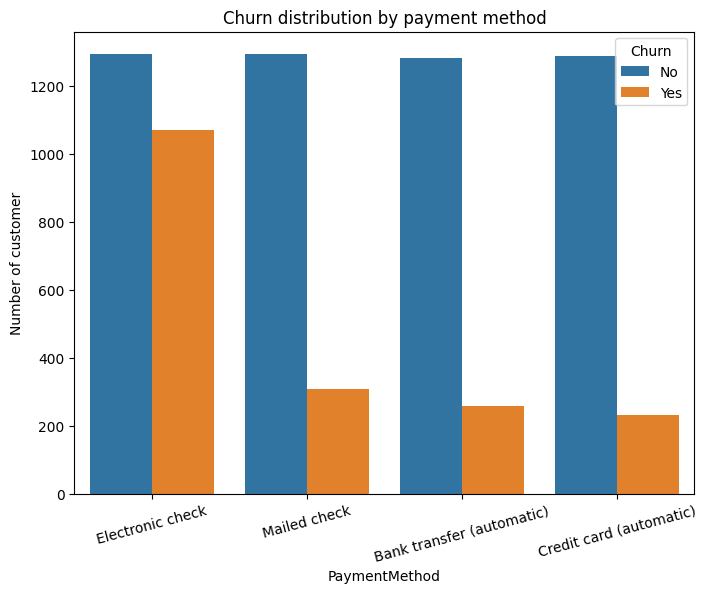

In [60]:
plt.figure(figsize=(8,6))
sns.countplot(data = telco_data,x='PaymentMethod',hue='Churn')
plt.title('Churn distribution by payment method')
plt.ylabel("Number of customer")
plt.xticks(rotation=15)
plt.show()

- Customers using Electronic Check have a noticeably higher churn count than customers using other payment methods, while customers using automatic payment methods have comparatively lower churn.

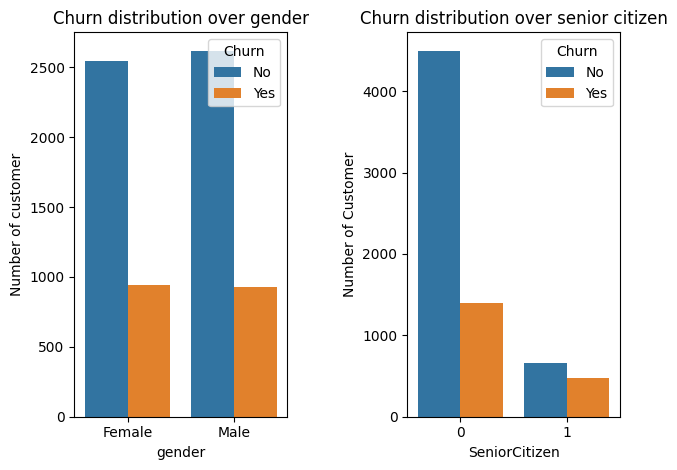

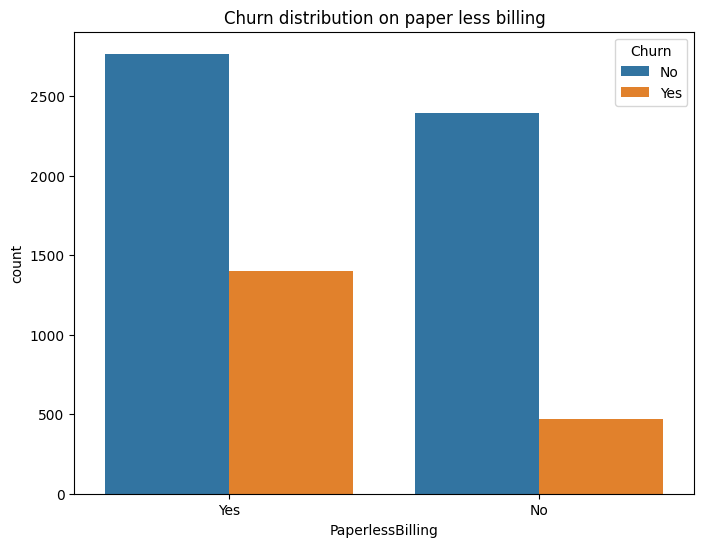

In [99]:
plt.subplot(1,2,1)
sns.countplot(data = telco_data,x='gender',hue='Churn')
plt.title('Churn distribution over gender')
plt.ylabel("Number of customer")
plt.subplot(1,2,2)
sns.countplot(data=telco_data,x='SeniorCitizen',hue='Churn')
plt.title("Churn distribution over senior citizen")
plt.ylabel("Number of Customer")
plt.tight_layout(w_pad=4.0)


plt.figure(figsize=(8,6))
sns.countplot(data =telco_data,x='PaperlessBilling',hue='Churn')
plt.title('Churn distribution on paper less billing')
plt.show()

In [66]:
telco_data['ChurnFlag'] = np.where(telco_data['Churn'] == 'Yes',1,0) 

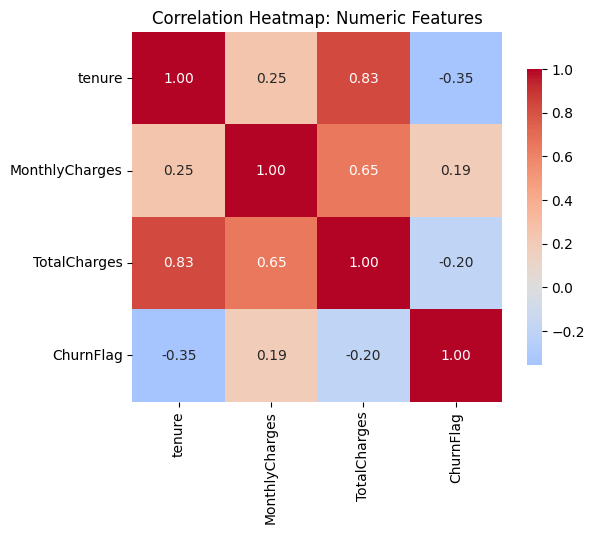

In [72]:
numeric_cols = ['tenure','MonthlyCharges','TotalCharges','ChurnFlag']
corr = telco_data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap: Numeric Features")
plt.show()

In [105]:
telco_data.to_csv("../data/churn_cleaned.csv",index=False)